Environment: the `etunc` kernel (`envs/etunc.yml`, with the repo installed editable).

# Testing `na_thres` for conservative regridding of obs

`regrid_obs.py` regrids the 0.1° obs products to 0.5° and 1° with xESMF first-order conservative
regridding and `skipna=True`. Each coarse cell is the area-weighted mean of its valid fine cells, and
`na_thres` decides when a partly missing coarse cell becomes NaN. The script uses `NA_THRES = 0.5`.

From `xesmf.BaseRegridder._regrid` (v0.9.2), a coarse cell is **kept** when

$$f_\text{valid} \ge \operatorname{clip}(1 - \text{na\_thres},\ 10^{-6},\ 1 - 10^{-6}),$$

where $f_\text{valid}$ is the area fraction of the coarse cell covered by non-NaN source cells. So:

- `na_thres = 0` keeps only cells that are fully valid (in practice, $f_\text{valid} \ge 1 - 10^{-6}$),
- `na_thres = 1` keeps any cell with any valid data,
- `na_thres = 0.5` keeps cells that are at least half valid. For GLEAM, where NaN means ocean, that
  is close to the `LF_THRESH = 0.5` land-fraction cut that `binned_et` applies to the models.

This notebook regrids one month of GLEAM E at each threshold. It compares how much land area each
threshold keeps and how well each one conserves the global E total. The area and total statistics use
the `binned_et.LAT_BNDS` domain (no Antarctica), since that is the domain the binning uses.

Floating-point round-off leaves many interior cells with $1 - f_\text{valid} \approx 10^{-15}$, so
"partial" cells below are those with $10^{-6} < f_\text{valid} < 1 - 10^{-6}$, using xESMF's own tolerance.


In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs

import etunc.load.obs as lo
import etunc.grid as rg

In [ ]:
VERSION = "v4.3a"
VAR = "E"
MONTH = "2010-07"
THRESHOLDS = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
RESOLUTIONS = rg.RESOLUTIONS  # {"0.5deg": 0.5, "1deg": 1.0}
ZOOM = dict(lon=slice(95, 130), lat=slice(-10, 20))  # Maritime Continent: many islands and coasts
TOL = 1e-6  # xESMF tolerance on the valid fraction
LAT_BNDS = slice(-58, 90)  # same as etunc.config.LAT_BNDS to exclude Antarctica
R_EARTH = 6.371e6  # m

## Load one month of GLEAM E (0.1°)

mm.month-1 (1800, 3600) valid fraction of cells: 0.341


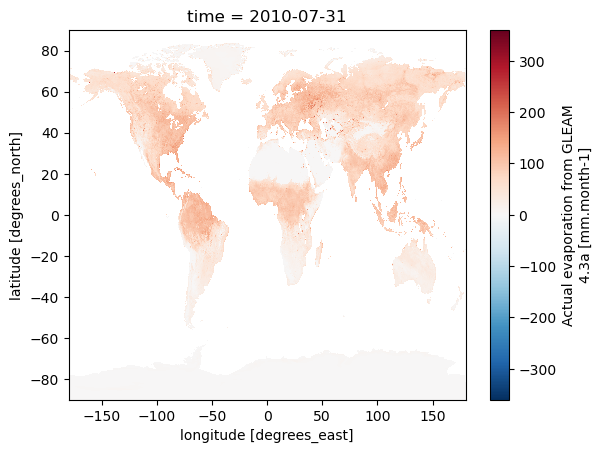

In [10]:
da = lo.load_obs("gleam", VAR, slice(MONTH, MONTH), version=VERSION, chunks=None).squeeze("time").load()
valid_src = da.notnull()
print(da.attrs["units"], da.shape, f"valid fraction of cells: {float(valid_src.mean()):.3f}")
# da
da.plot()

In [4]:
def cell_area(lat: xr.DataArray, lon: xr.DataArray) -> xr.DataArray:
    """Area [m2] of regular lat/lon cells with the given centers."""
    lat_b = np.clip(rg.cell_bounds(lat.values, "lat"), -90, 90)
    lon_b = rg.cell_bounds(lon.values, "lon")
    dy = np.diff(np.sin(np.deg2rad(lat_b)))
    dx = np.deg2rad(np.diff(lon_b))
    return xr.DataArray(R_EARTH**2 * np.outer(dy, dx), coords={"lat": lat, "lon": lon}, dims=("lat", "lon"))


da_dom = da.sel(lat=LAT_BNDS)
area_src = cell_area(da_dom["lat"], da_dom["lon"])
w_src = area_src.where(da_dom.notnull(), 0)

# E is mm/month: mm * m2 = 1e-3 m3, so * 1e-12 gives km3/month
native = {
    "valid_area_Mkm2": float(w_src.sum()) * 1e-12,
    "total_km3": float((da_dom * area_src).sum()) * 1e-12,
    "mean_mm": float(da_dom.weighted(w_src).mean()),
}
native

{'valid_area_Mkm2': 134.4603957473882,
 'total_km3': 8016.215309984286,
 'mean_mm': 59.61766857390787}

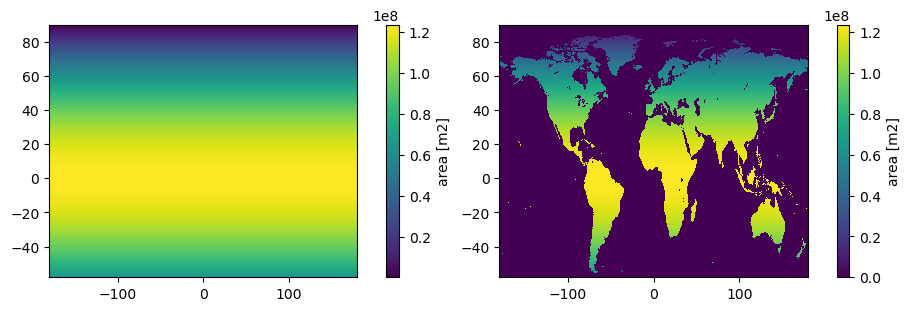

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(9,3), layout="constrained")
area_src.plot(ax=axs[0], cbar_kwargs={"label": "area [m2]"}, add_labels=False)
w_src.plot(ax=axs[1], cbar_kwargs={"label": "area [m2]"}, add_labels=False)

## Regrid at each threshold

`frac` is the valid-area fraction $f_\text{valid}$ of each coarse cell, found by regridding the
0/1 validity mask conservatively. The `assert` checks that each threshold keeps exactly the
cells the formula above predicts.

In [15]:
frac, out = {}, {}
for tag, res in RESOLUTIONS.items():
    regridder = rg.conservative_regridder(da, res)
    frac[tag] = regridder(valid_src.astype("float64"))
    # same call as rg.regrid_with_na_thres, with na_thres varied
    out[tag] = xr.concat(
        [regridder(da, skipna=True, na_thres=t) for t in THRESHOLDS],
        dim=pd.Index(THRESHOLDS, name="na_thres"),
    )
    for t in THRESHOLDS:
        expected = frac[tag] >= np.clip(1 - t, TOL, 1 - TOL)
        assert (out[tag].sel(na_thres=t).notnull() == expected).all(), (tag, t)
    print(f"{tag}: {out[tag].sizes['lat']}x{out[tag].sizes['lon']}, mask matches the formula for every threshold")

0.5deg: 360x720, mask matches the formula for every threshold
1deg: 180x360, mask matches the formula for every threshold


## Area kept and conservation of the global total

For each resolution and threshold:

- `n_cells` and `kept_area_pct` give the number of kept cells and their full area, as a percentage of the native valid (land) area.
- `land_area_pct` gives the valid area actually inside the kept cells, $\sum A\,f_\text{valid}$. It is below 100% when partly valid cells are dropped.
- `total_err_pct` is the error in the global E total computed the usual way, $\sum E\,A$ over kept cells. Kept partial cells count their ocean area as land, and dropped cells lose their land area.
- `total_frac_err_pct` is the same with each cell weighted by its valid fraction, $\sum E\,A\,f_\text{valid}$. It is exact at `na_thres = 1` up to the difference between ESMF great-circle cells and lat/lon cells.
- `mean_err_pct` is the error in the area-weighted mean E over kept cells, relative to the native land mean.

In [16]:
rows = []
for tag in RESOLUTIONS:
    o = out[tag].sel(lat=LAT_BNDS)
    area = cell_area(o["lat"], o["lon"])
    f = frac[tag].sel(lat=LAT_BNDS).fillna(0)
    for t in THRESHOLDS:
        e = o.sel(na_thres=t)
        kept = e.notnull()
        rows.append({
            "res": tag,
            "na_thres": t,
            "n_cells": int(kept.sum()),
            "kept_area_pct": 100 * float(area.where(kept).sum()) * 1e-12 / native["valid_area_Mkm2"],
            "land_area_pct": 100 * float((area * f).where(kept).sum()) * 1e-12 / native["valid_area_Mkm2"],
            "total_err_pct": 100 * (float((e * area).sum()) * 1e-12 / native["total_km3"] - 1),
            "total_frac_err_pct": 100 * (float((e * area * f).sum()) * 1e-12 / native["total_km3"] - 1),
            "mean_err_pct": 100 * (float(e.weighted(area.where(kept, 0)).mean()) / native["mean_mm"] - 1),
        })
summary = pd.DataFrame(rows).set_index(["res", "na_thres"])
summary.round(2)

n_cells  kept_area_pct  land_area_pct  total_err_pct  \
res    na_thres                                                         
0.5deg 0.00        55947          92.09          92.09          -9.26   
       0.10        57624          94.41          94.32          -6.67   
       0.25        59273          96.68          96.18          -4.02   
       0.50        61498          99.79          98.10          -0.31   
       0.75        63759         103.00          99.31           3.71   
       0.90        65827         106.06          99.85           7.39   
       1.00        68173         109.81         100.00          11.17   
1deg   0.00        12951          86.05          86.05         -15.66   
       0.10        13752          90.67          90.49         -10.78   
       0.25        14386          94.21          93.42          -6.78   
       0.50        15365          99.56          96.77          -0.62   
       0.75        16359         105.33          98.91           6.29   
       0.90        17108         109.96          99.69          12.00   
       1.00        18460         118.89         100.00          19.98   

                 total_frac_err_pct  mean_err_pct  
res    na_thres                                    
0.5deg 0.00                   -9.26         -1.46  
       0.10                   -6.78         -1.14  
       0.25                   -4.60         -0.73  
       0.50                   -2.30         -0.09  
       0.75                   -0.79          0.68  
       0.90                   -0.15          1.26  
       1.00                    0.00          1.24  
1deg   0.00                  -15.66         -1.99  
       0.10                  -10.97         -1.60  
       0.25                   -7.67         -1.05  
       0.50                   -3.81         -0.18  
       0.75                   -1.26          0.90  
       0.90                   -0.31          1.85  
       1.00                    0.00          0.92

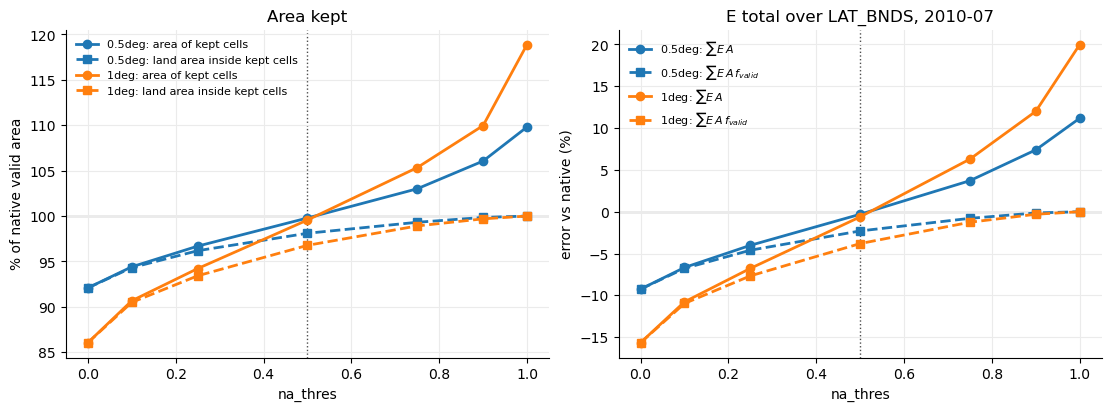

In [18]:
colors = {"0.5deg": "C0", "1deg": "C1"}
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

ax = axes[0]
for tag in RESOLUTIONS:
    s = summary.loc[tag]
    ax.plot(s.index, s["kept_area_pct"], "-o", color=colors[tag], lw=2, ms=6, label=f"{tag}: area of kept cells")
    ax.plot(s.index, s["land_area_pct"], "--s", color=colors[tag], lw=2, ms=6, label=f"{tag}: land area inside kept cells")
ax.axhline(100, color="0.6", lw=1, zorder=0)
ax.set(xlabel="na_thres", ylabel="% of native valid area", title="Area kept")

ax = axes[1]
for tag in RESOLUTIONS:
    s = summary.loc[tag]
    ax.plot(s.index, s["total_err_pct"], "-o", color=colors[tag], lw=2, ms=6, label=f"{tag}: $\\sum E\\,A$")
    ax.plot(s.index, s["total_frac_err_pct"], "--s", color=colors[tag], lw=2, ms=6, label=f"{tag}: $\\sum E\\,A\\,f_{{valid}}$")
ax.axhline(0, color="0.6", lw=1, zorder=0)
ax.set(xlabel="na_thres", ylabel="error vs native (%)", title=f"E total over LAT_BNDS, {MONTH}")

for ax in axes:
    ax.axvline(rg.NA_THRES, color="0.3", lw=1, ls=":", zorder=0)
    ax.grid(color="0.92")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, fontsize=8)
plt.show()

## Where the thresholds differ

Only coastal and lake cells with $0 < f_\text{valid} < 1$ depend on `na_thres`. The left map shows
$f_\text{valid}$ for those partial cells at 1°. The histogram shows how they are spread across
$f_\text{valid}$, which sets how many cells each threshold drops.

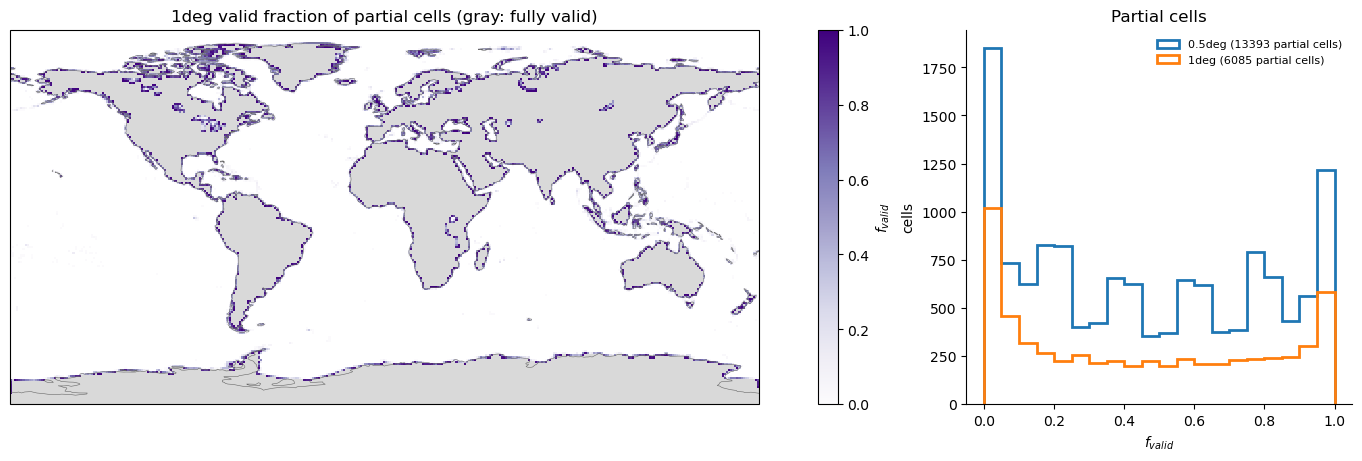

In [25]:
regrid_res = "1deg"

fig = plt.figure(figsize=(14, 4.5), constrained_layout=True, dpi=100)
gs = fig.add_gridspec(1, 3, width_ratios=[2.2, 0.05, 1])

ax = fig.add_subplot(gs[0], projection=ccrs.PlateCarree())
f1 = frac[regrid_res]
# f1 = frac[regrid_res]
partial = f1.where((f1 > TOL) & (f1 < 1 - TOL))
ax.pcolormesh(f1["lon"], f1["lat"], f1.where(f1 >= 1 - TOL), cmap=mcolors.ListedColormap(["0.85"]),
              transform=ccrs.PlateCarree())
pm = ax.pcolormesh(partial["lon"], partial["lat"], partial, cmap="Purples", vmin=0, vmax=1,
                   transform=ccrs.PlateCarree())
ax.coastlines(lw=0.4, color="0.4")
ax.set_global()
ax.set_title(f"{regrid_res} valid fraction of partial cells (gray: fully valid)")
fig.colorbar(pm, cax=fig.add_subplot(gs[1]), label="$f_{valid}$")

ax = fig.add_subplot(gs[2])
bins = np.linspace(0, 1, 21)
for tag in RESOLUTIONS:
    f = frac[tag].values.ravel()
    f = f[(f > TOL) & (f < 1 - TOL)]
    ax.hist(f, bins=bins, histtype="step", lw=2, color=colors[tag], label=f"{tag} ({f.size} partial cells)")
ax.set(xlabel="$f_{valid}$", ylabel="cells", title="Partial cells")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8)
plt.show()

## Zoom on a coastal region

Native 0.1° E next to the 1° fields at `na_thres` = 0, 0.5 and 1, all on the same color scale.
At 0 the islands mostly disappear. At 1 every cell that touches land is filled with the
land-mean value, including open-ocean cells whose only valid source cells are a tiny island.
Gray is NaN, so it can be told apart from E = 0.

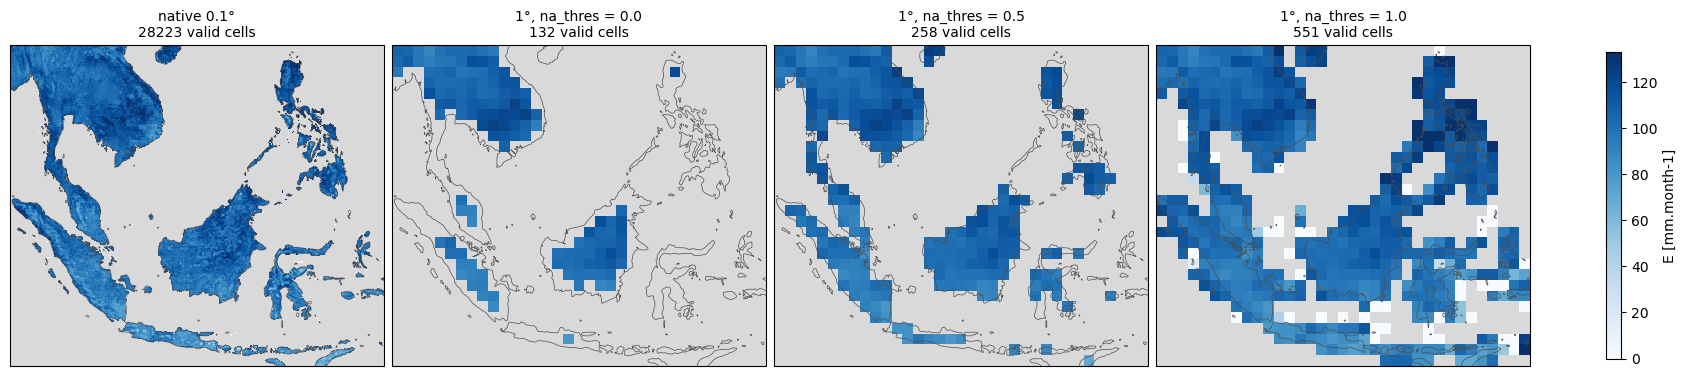

In [9]:
panels = [("native 0.1°", da.sel(**ZOOM))] + [
    (f"1°, na_thres = {t}", out["1deg"].sel(na_thres=t, **ZOOM)) for t in (0.0, rg.NA_THRES, 1.0)
]
vmax = float(da.sel(**ZOOM).quantile(0.98))

fig, axes = plt.subplots(1, len(panels), figsize=(4.2 * len(panels), 4), constrained_layout=True,
                         subplot_kw={"projection": ccrs.PlateCarree()})
for ax, (title, field) in zip(axes, panels):
    pm = ax.pcolormesh(field["lon"], field["lat"], field, cmap="Blues", vmin=0, vmax=vmax,
                       transform=ccrs.PlateCarree())
    ax.set_facecolor("0.85")
    ax.coastlines(lw=0.5, color="0.3")
    ax.set_extent([ZOOM["lon"].start, ZOOM["lon"].stop, ZOOM["lat"].start, ZOOM["lat"].stop], ccrs.PlateCarree())
    n = int(field.notnull().sum())
    ax.set_title(f"{title}\n{n} valid cells", fontsize=10)
fig.colorbar(pm, ax=axes, shrink=0.8, label=f"{VAR} [{da.attrs['units']}]")
plt.show()

## Takeaways (GLEAM v4.3a E, 2010-07)

- Only coastal and lake cells depend on the threshold: about 13k cells at 0.5° and 6k at 1°. They
  are spread fairly evenly over $f_\text{valid}$, so each threshold step drops a similar number.
- With the usual $\sum E\,A$ total, `na_thres = 0.5` comes within about 0.5% of the native total at
  both resolutions. Dropped cells that are mostly land roughly cancel the ocean area counted in kept
  cells. At 1° the total is off by -16% at 0 and +20% at 1.
- The land-area-weighted total $\sum E\,A\,f_\text{valid}$ is exact at `na_thres = 1`. At 0.5 it is
  low by 2-4%, because the land in dropped cells is lost.
- The mean E over kept cells changes by at most about 2% across thresholds, and by about 0.2% at 0.5.
- `na_thres = 0.5` is close in spirit to `binned_et.LF_THRESH = 0.5`, so the current `NA_THRES` is a
  reasonable default. If you later want to apply model land fractions to the obs, regrid with
  `na_thres = 1` and also save $f_\text{valid}$.
